# Import

In [1]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline
import warnings
import matplotlib
import matplotlib.pyplot as plt
import sys 
import os 
import pandas as pd
import anndata as ad
import scanpy as sc
import numpy as np
import seaborn as sns
from tqdm import tqdm
import subprocess
from sklearn.metrics import r2_score

import pandas as pd
from scipy.stats import linregress
import matplotlib.patches as mpatches
from scipy.stats import pearsonr, spearmanr
from pandas.api.types import CategoricalDtype
from scipy.cluster.hierarchy import linkage
from matplotlib.patches import Patch
from statsmodels.stats.multitest import multipletests
# pd.set_option('display.max_columns', None)
# pd.set_option('display.max_colwidth', None)
# np.set_printoptions(threshold=np.inf)

plt.rcParams["figure.figsize"]=4,4

warnings.filterwarnings("ignore")

# - dirs 
from ciim.src.common import palette_treatment, mapping_major_2_minor, mapping_minor_2_major, cell_types, datasets_e, datasets_all, datasets_a, palette_datasets, palette_datasets_pretty, surrogate_names, colors_blind, palette_trend, palette_trend_2, palette_regulation, palette_cell_types

from ciim.src.tf_activity.helper import retrieve_feature_data, retrieve_adata_bulk, retrieve_net, calculate_tf_activity, retrieve_sig_stats
from ciim.src.tf_activity.plots import  plot_net_nx, plot_trend_tfs

from ciim.src.utils.plots import dotplot

/Users/jno24/miniconda3/envs/py10/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/Users/jno24/miniconda3/envs/py10/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/Users/jno24/miniconda3/envs/py10/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/Users/jno24/miniconda3/envs/py10/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/Users/jno24/miniconda3/envs/py10/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing 

# In silico prediction

In [2]:
type = 'bulk' 
race = 'european'
cell_type = 'CD8T'
min_degree = 3 # shared edges in nets
alpha = .1 # ratio of the whole change to be applied in the simulation alpha*max_delta
n_iter = 10
age_range = [20, 75]
# net = retrieve_net(dataset, cell_type)[['source', 'target', 'weight']]
if race == 'european':
    datasets = datasets_e
else:
    datasets = datasets_a

In [7]:
def prepare_inputs(type, race, dataset, cell_type, min_degree, age_range=[20, 75]):
    from ciim.src.tf_activity.helper import get_consensus_net

    # - read inputs
    if False:
        stats_targets = pd.read_csv(f'../output/gene_expression/stats_all_{type}.csv')
        stats_sig = retrieve_sig_stats(type, race=race, filter_inconsistent=True).drop_duplicates(subset=['cell_type', 'tf'])
        stats_sig_target = stats_targets[(stats_targets['analysis'] == race) & (stats_targets['meta_p_adj'] < 0.05) & (stats_targets['trend']!= 'Inconsistent')].drop_duplicates(subset=['cell_type', 'target'])

        sig_tfs = stats_sig['tf'].unique()

        # - prepare the net
        sig_targets = stats_sig_target['target'].unique()
        net = get_consensus_net(datasets_e, cell_type, min_degree)
        net = net[net['source'].isin(sig_tfs)]
        net = net[net['target'].isin(sig_targets)]
        print(np.setdiff1d(stats_sig['tf'].unique(), net['source'].unique()))
    else: #TODO: choose this based on the simulation aims. -> the sig net could be either promotr based on not
        if False: # - use the sig net
            net = pd.read_csv(f'../output/sig_nets/sig_nets_{type}_{race}.csv')
        else:
            net = get_consensus_net(datasets_all, cell_type, min_degree)
        net = net[net['cell_type'] == cell_type].copy()
    
    # - convert net to a matrix (gene x tf)
    net_matrix_df = net.pivot(index='target', columns='source', values='weight').fillna(0)
    print(net_matrix_df.shape)

    # - prepare the expression data
    adata = retrieve_feature_data(dataset=dataset, cell_type=cell_type, type=type)
    adata = adata[~adata.obs['age'].isna()].copy()
    adata.obs['age'] = adata.obs['age'].astype(int)

    # - bin 5 years and take the mean of the expression values
    expr_df = pd.DataFrame(adata.X, index=adata.obs.index, columns=adata.var_names)
    expr_df['age'] = adata.obs['age']
    expr_df = expr_df[(expr_df['age'] > age_range[0]) & (expr_df['age'] < age_range[1])].copy()  # Filter out age ranges
    expr_df['age_bin'] = (expr_df['age'].astype(int) // 5) * 5
    expr_df = expr_df.groupby('age_bin').mean().drop(columns='age')

    # - keep only those genes which are in both
    # if False:
    common_genes = net_matrix_df.index.intersection(expr_df.columns)
    net_matrix_df = net_matrix_df.loc[common_genes]
    expr_df = expr_df[common_genes]

    # - define variables for the simulation
    max_delta = (expr_df.max() - expr_df.min()).values

    return net_matrix_df, expr_df, max_delta
# - run simulation

def prepare_p(net_matrix_df, perturb_tfs, max_delta):
    '''Gets tf names and create a p vector with the same column as N, where the given tfs are set to given values'''
    all_tfs = net_matrix_df.columns
    p = np.zeros_like(all_tfs, dtype=float)
    missing_tfs = [tf for tf in perturb_tfs if tf not in all_tfs]
    if missing_tfs:
        print("Missing TFs:", missing_tfs)
        perturb_tfs = [tf for tf in perturb_tfs if tf in all_tfs]  # filter only valid ones

    idxs = [np.where(all_tfs == tf)[0][0] for tf in perturb_tfs]
    for idx in idxs:
        p[idx] = max_delta[idx]  # or scale this as you like
    return p

def combinatorial_experiments(net_matrix_df, expr_df, max_delta, perturb_tfs=None, combinations=[1, 2], n_iter=10):
    import itertools
    all_tfs = net_matrix_df.columns
    N = net_matrix_df.values
    X0 = expr_df.iloc[0, :].values
    if perturb_tfs is None:
        perturb_tfs = all_tfs
    perturb_tfs = np.asarray(perturb_tfs)
    results = []
    # loop over single and pairwise TF combinations
    for k in combinations:  # 1 = single, 2 = pairs
        for perturb_tfs_i in itertools.combinations(perturb_tfs, k):
            p = prepare_p(net_matrix_df, perturb_tfs_i, max_delta)
            # run the simulation
            Xs = run_simulation(N, X0, p, n_iter=n_iter)
            X = Xs[-1]

            # measure impact
            rho, _ = spearmanr(X0, X)
            impact = 1 - rho  # higher = more change

            results.append({
                'tf': perturb_tfs_i if k > 1 else perturb_tfs_i[0],
                'impact': impact,
                'num_TFs': k
            })
    # convert to DataFrame
    impact_df = pd.DataFrame(results)
    return impact_df


## Simulated pattern vs real

In [9]:
from ciim.src.tf_activity.helper import retrieve_sig_stats
from ciim.src.insilico_perturbation.helper import run_simulation
# - test run
dataset = datasets_e[1]
net_matrix_df, expr_df, max_delta = prepare_inputs(type=type, race=race, dataset=dataset, cell_type=cell_type, min_degree=min_degree)

# - sig stats
stats_sig = retrieve_sig_stats(type='bulk', race='european', filter_inconsistent=True)
stats_sig = stats_sig[stats_sig['cell_type'] == cell_type]
perturb_tfs = stats_sig['tf'].unique()
n_iter = len(expr_df.index)
predict_expr = run_simulation(net_matrix_df.values, expr_df.iloc[0, :].values, prepare_p(net_matrix_df, perturb_tfs, max_delta*alpha), n_iter=n_iter)
predict_expr_df = pd.DataFrame(predict_expr, columns=expr_df.columns, index=expr_df.index)

(2918, 263)
Missing TFs: ['MAX']


IndexError: index 179 is out of bounds for axis 0 with size 179

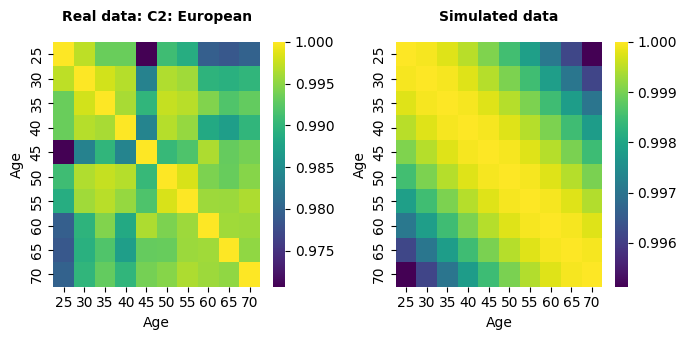

In [46]:
corr_o = expr_df.T.corr()
corr_s = predict_expr_df.T.corr()
fig, axes = plt.subplots(1, 2, figsize=(7, 3.5), sharey=False)
ax = axes[0]
sns.heatmap(corr_o, ax=ax, cmap='viridis')
ax.set_title(f'Real data: {surrogate_names[dataset]}', fontsize=10, fontweight='bold', pad=15)
ax.set_xlabel('Age')
ax.set_ylabel('Age')
ax = axes[1]
sns.heatmap(corr_s, ax=ax, cmap='viridis')
ax.set_title(f'Simulated data', fontsize=10, fontweight='bold', pad=15)
ax.set_xlabel('Age')
ax.set_ylabel('Age')
plt.tight_layout()
# .style.background_gradient(cmap='viridis', low=0, high=1, axis=1)

In [48]:
adata_real

AnnData object with n_obs × n_vars = 10 × 2637
    obs: 'age_bin', 'cell_type', 'predicted_age'

In [50]:
from ciim.src.clock.helper import predict_age

adata_real = ad.AnnData(X=expr_df.values, obs=expr_df.index.to_frame(index=False).rename({'age_bin':'age'}, axis=1), var=pd.DataFrame(index=expr_df.columns))
adata_pred = ad.AnnData(X=predict_expr_df.values, obs=predict_expr_df.index.to_frame(index=False), var=pd.DataFrame(index=predict_expr_df.columns))

adata_real.obs['cell_type'] = cell_type
predict_age(adata_real, cell_type)

KeyError: 'donor_id'

## combinatorial experiments

In [52]:
# - run combinatorial experiments
impact_df_store = []
for dataset in datasets:
    net_matrix_df, expr_df, max_delta = prepare_inputs(type=type, race=race, dataset=dataset, cell_type=cell_type, min_degree=min_degree)
    impact_df = combinatorial_experiments(net_matrix_df, expr_df, max_delta, combinations=[1], n_iter=n_iter)
    impact_df = impact_df.sort_values('impact', ascending=False)
    # impact_df['impact'] = impact_df['impact']/impact_df['impact'].max()
    impact_df['dataset'] = dataset
    impact_df_store.append(impact_df)
impact_df = pd.concat(impact_df_store)

(589, 102)
(589, 102)
(589, 102)


Text(0.5, 1.0, 'Asian-CD8T')

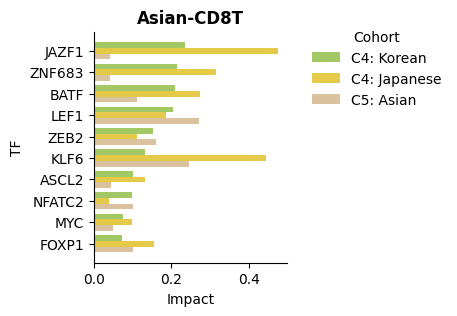

In [53]:
# - subset to top tfs
top_tfs = impact_df.groupby('tf').agg({'impact': 'mean'}).sort_values('impact', ascending=False).head(10).index
impact_df_sub = impact_df[impact_df['tf'].isin(top_tfs)]
# - plot
impact_df_sub['dataset'] = impact_df_sub['dataset'].map(surrogate_names)
fig, ax = plt.subplots(figsize=(2.5, 3))
sns.barplot(data=impact_df_sub, hue='dataset', y='tf', x='impact', alpha=1, palette=palette_datasets_pretty, dodge=True, ax=ax)
ax.set_xlabel('Impact')
ax.set_ylabel('TF')
ax.margins(x=0.05, y=0.05)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(loc=(1.1, .65), frameon=False, title='Cohort', fontsize=10)
ax.set_title(f'{surrogate_names[race]}-{cell_type}', fontsize=12, fontweight='bold')

In [45]:
# - check the corr between age groups
expr_df.T.corr().style.background_gradient(cmap='viridis', low=0, high=1, axis=1)

age_bin,20,25,30,35,40,45,50,55,60,65,70
age_bin,,,,,,,,,,,
20,1.000000,0.996428,0.996723,0.992152,0.982596,0.988149,0.971207,0.972447,0.971436,0.982432,0.964672
25,0.996428,1.000000,0.998005,0.994229,0.987590,0.989393,0.977543,0.979394,0.978019,0.987008,0.970507
30,0.996723,0.998005,1.000000,0.996814,0.990728,0.993209,0.982148,0.984012,0.982220,0.990686,0.975635
35,0.992152,0.994229,0.996814,1.000000,0.995514,0.997174,0.990156,0.990813,0.989731,0.995134,0.984850
40,0.982596,0.987590,0.990728,0.995514,1.000000,0.995817,0.995638,0.996071,0.995326,0.996518,0.992197
45,0.988149,0.989393,0.993209,0.997174,0.995817,1.000000,0.992141,0.991815,0.990737,0.994696,0.987817
50,0.971207,0.977543,0.982148,0.990156,0.995638,0.992141,1.000000,0.997362,0.996595,0.994715,0.995858
55,0.972447,0.979394,0.984012,0.990813,0.996071,0.991815,0.997362,1.000000,0.996763,0.995218,0.994203
60,0.971436,0.978019,0.982220,0.989731,0.995326,0.990737,0.996595,0.996763,1.000000,0.994561,0.994269


In [46]:
if False:
    # - create perturbation
    tf_case = 'BATF' # 'LEF1'
    tf_idx = np.where(tfs == tf_case)[0][0]
    p = np.zeros_like(tfs, dtype=float)  # or same shape as tfs
    p[tf_idx] = max_delta[tf_idx]

    
    X = run_simulation(N, X0, p, n_iter=10)

    # - evaluate the change 
    from scipy.stats import spearmanr
    from scipy.stats import pearsonr
    # print(f'Spearman (initial vs end X)', spearmanr(X0, X_end))
    print(f'Spearman (prediction vs initial X)', spearmanr(X0, X))
    # print(f'Spearman (prediction vs end X)', spearmanr(X_end, X))

# Case TFs

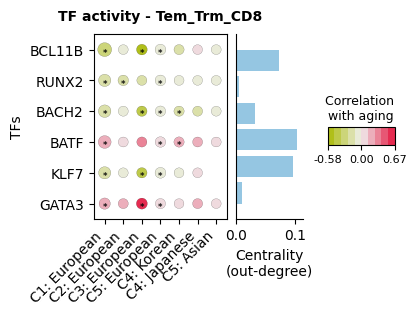

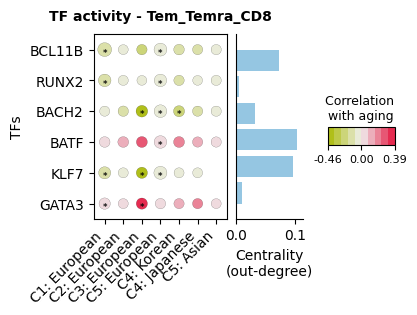

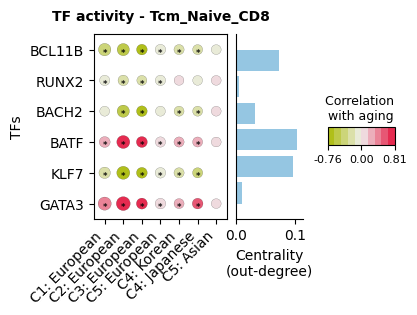

In [50]:
from ciim.src.tf_activity.plots import plot_features_vs_datasets

ttypes = ['Tem_Trm_CD8',
                'Tem_Temra_CD8',
                'Tcm_Naive_CD8']
features = ['BCL11B', 'RUNX2', 'BACH2', 'BATF', 'KLF7', 'GATA3']
type = 'bulk_minor'
for cell_type in ttypes:
    plot_features_vs_datasets(cell_type=cell_type, type=type, datasets=datasets_all, features=features, width=3.5,
                                feature_type='tf_activity', sizes=(50, 100), min_degree=1, filter_meta_significant=True)
# plt.savefig(f'../output/test.png', bbox_inches='tight', dpi=300)

# GATA3

In [2]:
case_tf = 'GATA3'  # 'TCF7' 'SATB1' 
type = 'bulk'
race = 'both'
n_top_targets = 10
selected_cell_types = ['CD8T', 'CD4T', 'NK'] # ['CD8T', 'CD4T', 'NK'] #Tcm_Naive_CD8
n_panels = len(selected_cell_types)

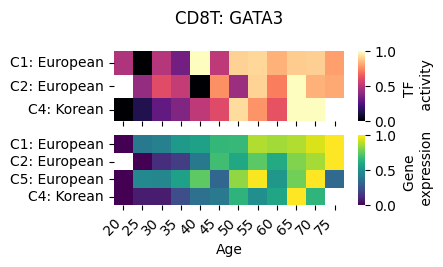

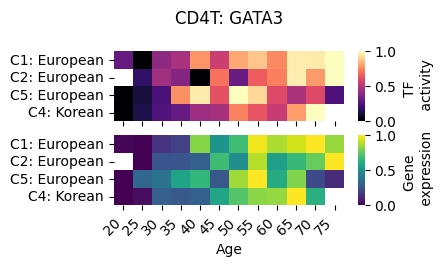

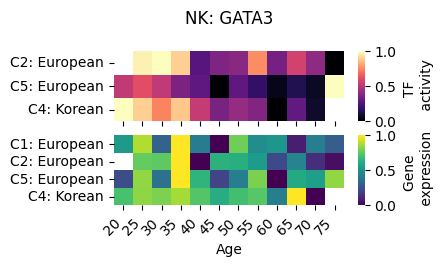

In [7]:
from ciim.src.tf_activity.plots import plot_feature_values_all_datasets, plot_feature_values_per_datasets

if '_M' in type:
    datasets = ['data1', 'data7_allTPs_jalil', 'data13_Korean']
elif '_F' in type:
    datasets = ['data1', 'SLE_European', 'data13_Korean']
else:
    datasets = ['data1', 'data7_allTPs_jalil', 'SLE_European', 'data13_Korean']

plot_both = True

for cell_type in selected_cell_types:
    if plot_both:
        fig, axes = plt.subplots(2, 1, figsize=(3.5, 2), sharex=True)
    else:
        fig, ax = plt.subplots(1, 1, figsize=(3.5, .7))

    ax = axes[0] if plot_both else ax
    plot_feature_values_all_datasets(cell_type, feature=case_tf, feature_type='tf_activity', type=type, datasets=datasets, show_cbar=True, ax=ax)
    if plot_both:
        ax.set_xlabel('')
        ax = axes[1]
        plot_feature_values_all_datasets(cell_type, feature=case_tf, feature_type='gene_expression', type=type, datasets=datasets, show_cbar=True, ax=ax)
        ax.set_title('')

In [19]:
nets_sig = pd.read_csv(f'../output/sig_nets/sig_nets_{type}_{race}.csv')
nets_sig = nets_sig[(nets_sig['source']==case_tf) & (nets_sig['cell_type'].isin(selected_cell_types))].copy()
n_targets = 10

In [20]:
if False:
    from ciim.src.tf_activity.plots import plot_net_nx
    
    for cell_type in selected_cell_types:
        net = nets_sig[(nets_sig['cell_type']==cell_type)]
        if True: # filter based on weight
            if net.shape[0]>n_targets:
                net = net.sort_values('weight', ascending=False, key=abs).head(n_targets)
        else: # targetted filter
            net = net[net['target'].isin(['FOS', 'FOSB', 'JUNB'])].copy()
        plot_net_nx(net, figsize=(4, 4))
        plt.tight_layout()
        plt.title(f'{case_tf} - {cell_type}', pad=10, fontsize=15, fontweight='bold')

In [21]:
stats_targets = retrieve_sig_stats(type, feature_type='gene_expression', race=race)

targets_store = []
for cell_type in selected_cell_types:
    net = nets_sig[nets_sig['cell_type']==cell_type]
    targets = net.sort_values('weight', ascending=False, key=abs).head(n_targets)['target'].unique()
    targets_store.append(targets)
all_targets = np.concatenate(targets_store)


def select_top_targets(cell_type, tf, n_top=30):
    net_store = []
    for dataset in datasets:
        net = retrieve_net(dataset, cell_type)
        net = net[(net['source']==tf) & (net['target'].isin(all_targets))].copy()
    
        #- select targets
        stats = stats_targets[(stats_targets['target'].isin(all_targets)) & (stats_targets['dataset']==dataset) & (stats_targets['cell_type']==cell_type)]
        net = net.merge(stats[['target', 'p_value_adj', 'slope']], on='target', how='left')
        net['neg_log10_adj_pval'] = -np.log10(net['p_value_adj'])
        net['dataset'] = dataset

        net_store.append(net)
    net_tf = pd.concat(net_store)
    return net_tf

net_store = []
for cell_type in selected_cell_types:
    net = select_top_targets(cell_type, case_tf, n_top=n_top_targets)
    net['cell_type'] = cell_type
    net_store.append(net)
net_tf = pd.concat(net_store)

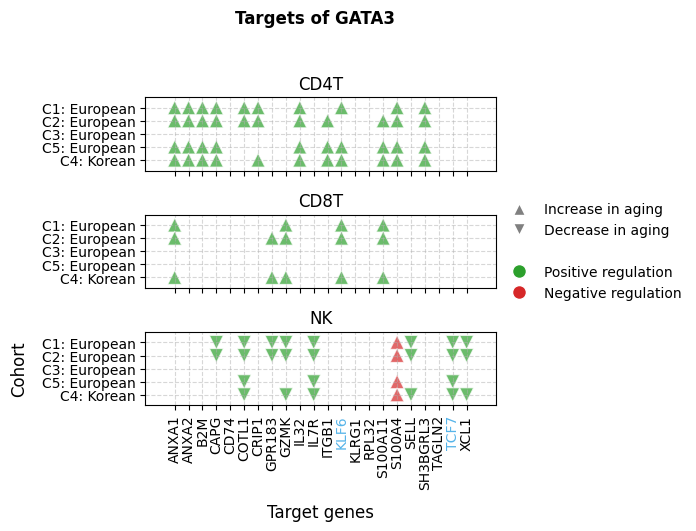

In [30]:
from ciim.src.tf_activity.plots import wrapper_flesh_out_tf_interactions, plot_tf_interactions_plus_target_stats_binary

n_top_genes_per_dataset=10
# - select 
shared_state = net_tf.groupby(['cell_type','target'])['dataset'].nunique()
selected_tuple = shared_state[shared_state>=3].index
net_tf = net_tf.set_index(['cell_type', 'target']).loc[selected_tuple].reset_index()

n_targets = net_tf['target'].nunique()
net_tf['target'] = net_tf['target'].astype('category')
net_tf['dataset'] = pd.Categorical(net_tf['dataset'], categories=datasets_all, ordered=True)
fig, axes = plt.subplots(n_panels, 1, figsize=(n_targets*.16 +1, len(datasets_all)*.5 + 1), sharex=True)

for i, (cell_type) in enumerate(net_tf['cell_type'].unique()):
    ax = axes[i] if n_panels > 1 else axes
    if i == 1:
        show_legend = True
    else:
        show_legend = False
    net = net_tf[net_tf['cell_type'] == cell_type]   
    net = net[net['neg_log10_adj_pval'] > 1.4]
    
    plot_tf_interactions_plus_target_stats_binary(net.copy(), ax=ax, show_legend=show_legend, sizes=(50, 200), annotate_sig=False, annotate_targets=True)

    ax.margins(y=0.2, x=0.1)
    ax.set_title(cell_type)
    ax.set_xlabel('Target genes')
    ax.grid(True, linestyle='--', alpha=0.5)
    if i != n_panels - 1:
        ax.set_ylabel('')
plt.suptitle(f'Targets of {case_tf}', y=1.1, weight='bold', fontsize=12)
plt.subplots_adjust(hspace=0.6)

In [ ]:
AP-1 FOS, FOSB, JUND

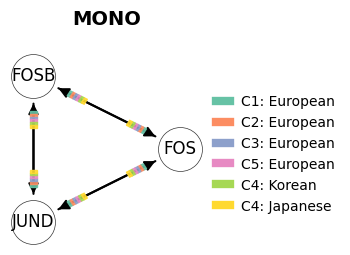

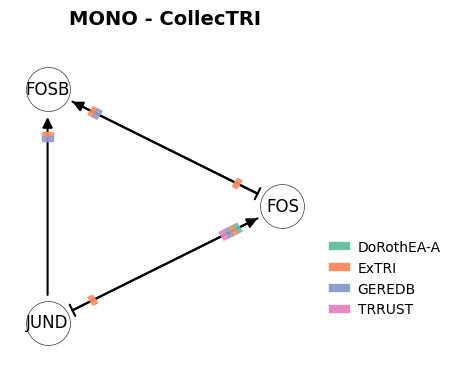

In [4]:
type = 'bulk'
cell_type = 'CD4T' #'Tcm_Naive_CD8'
n_top=10
# features = ['FOXO1', 'FOXO3', 'NFE2L2', 'TP53', 'SIRT1', 'HIF1A']
# features = ['GATA3', 'S100A4', 'GZMK', 'KLF6', 'COTL1', 'TCF7', 'ANXA1']
# features = ['GATA3', 'S100A4', 'GZMK', 'COTL1']
features = ['FOS', 'FOSB', 'JUND']
from ciim.src.tf_activity.plots import wrapper_draw_net
for cell_type in ['MONO']:
    wrapper_draw_net(cell_type, datasets_all, features, min_degree=3, indivitual_net=False, draw_evidence=True, draw_collectri=True, figsize=(2.5, 2.5), figsize_collectri=(4, 4), 
                    offset_evidence=.13, arc_offset=.05, only_promotor_based=False)